In [1]:
library(forecast)

Warning message:
"package 'forecast' was built under R version 4.5.2"
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



# Load cleaned data

In [2]:
unemp <- read.csv("eda_data.csv")
tail(unemp)

,month,unemployment_rate,total_employment,all_gdp
,<chr>,<dbl>,<dbl>,<int>
343,2025-07-01,6.9,21206.7,2337520
344,2025-08-01,7.1,21086.3,2336252
345,2025-09-01,7.1,21039.4,2339856
346,2025-10-01,6.9,21125.7,2332992
347,2025-11-01,6.6,21117.8,2333414
348,2025-12-01,6.8,21056.4,2339127


In [3]:
unemp_ts <- ts(unemp$unemployment_rate, start = c(1997, 1), frequency = 12)

# Use log of gdp as it's an economic indicator
unemp$log_gdp <- log(unemp$all_gdp)

# unemp$diff_emp <- c(NA, diff(unemp$total_employment))

In [4]:
cor(unemp$log_gdp,unemp$total_employment)

[1] 0.9821454

The high correlation rate between log_gdp and total_employment means we can chose to ignore total_employment to train models faster.

In [5]:
xreg_ts <- ts(unemp[, c("log_gdp")],
              start = c(1997, 1), frequency = 12)


# Test/Train split

In [66]:
unemp_train <- window(unemp_ts, end=c(2018,12))
unemp_test  <- window(unemp_ts, start=c(2019,1))

xreg_train <- window(xreg_ts, end=c(2018,12))
xreg_test  <- window(xreg_ts, start=c(2019,1))

length(unemp_train)
length(unemp_test)

[1] 264

[1] 84

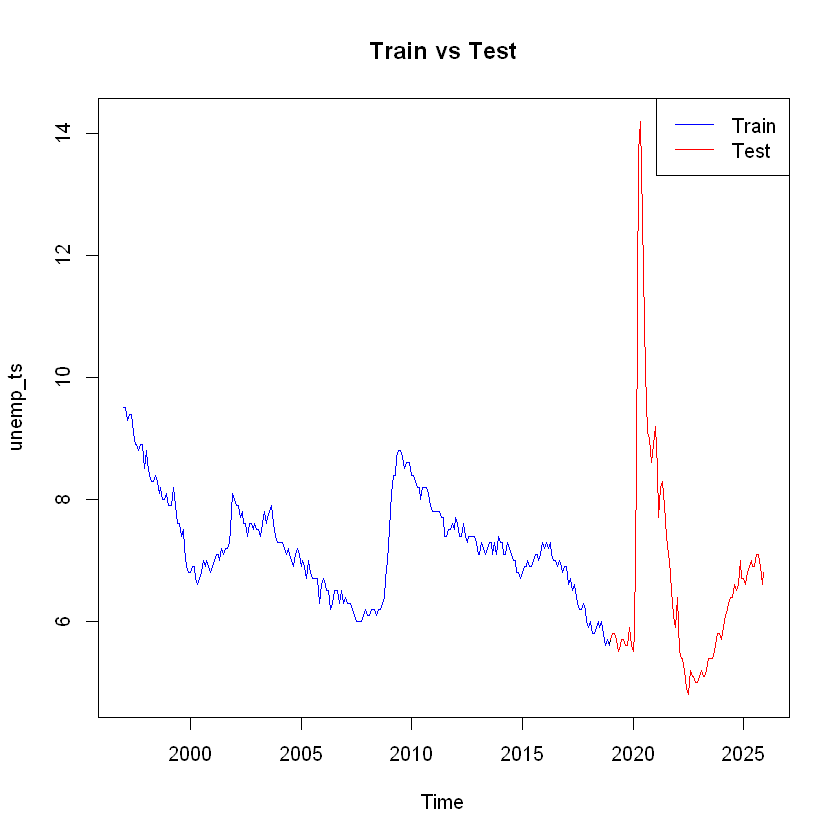

In [67]:
plot(unemp_ts, col="black", main="Train vs Test")
lines(unemp_train, col="blue")
lines(unemp_test, col="red")
legend("topright", legend=c("Train","Test"), col=c("blue","red"), lty=1)

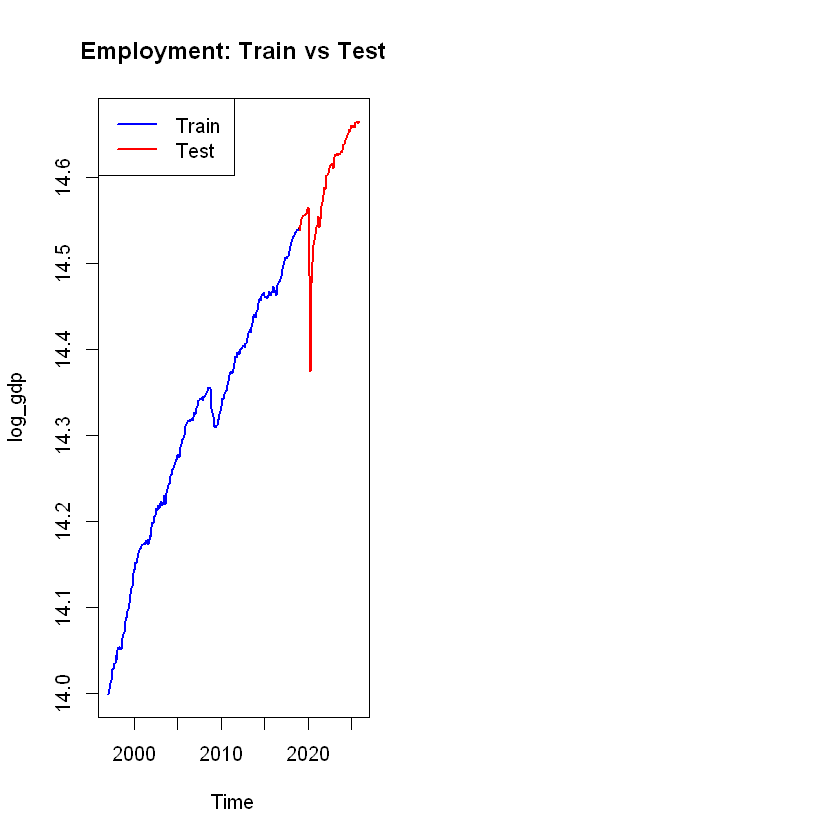

In [68]:
par(mfrow = c(1, 2))

plot(xreg_ts, col = "black", main = "Employment: Train vs Test", ylab = "log_gdp")
lines(xreg_train, col = "blue", lwd = 2)
lines(xreg_test, col = "red", lwd = 2)
legend("topleft", legend = c("Train", "Test"), col = c("blue", "red"), lty = 1, lwd = 2)


# plot(xreg_ts[, "log_gdp"], col = "black", main = "Employment: Train vs Test", ylab = "log_gdp")
# lines(xreg_train[, "log_gdp"], col = "blue", lwd = 2)
# lines(xreg_test[, "log_gdp"], col = "red", lwd = 2)
# legend("topleft", legend = c("Train", "Test"), col = c("blue", "red"), lty = 1, lwd = 2)

# plot(xreg_ts[, "total_employment"], col = "black", main = "Employment: Train vs Test", ylab = "diff_emp")
# lines(xreg_train[, "diff_emp"], col = "blue", lwd = 2)
# lines(xreg_test[, "diff_emp"], col = "red", lwd = 2)
# legend("topleft", legend = c("Train", "Test"), col = c("blue", "red"), lty = 1, lwd = 2)


In [69]:
armax_model_auto  <- auto.arima(unemp_train, xreg = xreg_train,
                           seasonal = TRUE,
                           stepwise = FALSE,
                           approximation = FALSE)

summary(armax_model_auto)

Series: unemp_train 
Regression with ARIMA(0,1,1)(0,0,2)[12] errors 

Coefficients:
          ma1     sma1     sma2   drift      xreg
      -0.1197  -0.3453  -0.1070  0.0230  -17.3906
s.e.   0.0649   0.0640   0.0609  0.0065    2.4895

sigma^2 = 0.01855:  log likelihood = 154.33
AIC=-296.67   AICc=-296.34   BIC=-275.24

Training set error measures:
                        ME      RMSE       MAE         MPE     MAPE      MASE
Training set -0.0002100046 0.1346365 0.1047598 -0.04371199 1.442263 0.2041722
                    ACF1
Training set 0.003474615

In [70]:
armax_fc_auto <- forecast(armax_model_auto, xreg = xreg_test)


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.0002100046,0.1346365,0.1047598,-0.04371199,1.442263,0.2041722,0.003474615,NA
Test set,0.7386363216,1.4952357,0.9964941,7.72621210,12.727591,1.9421231,0.923733039,1.732153


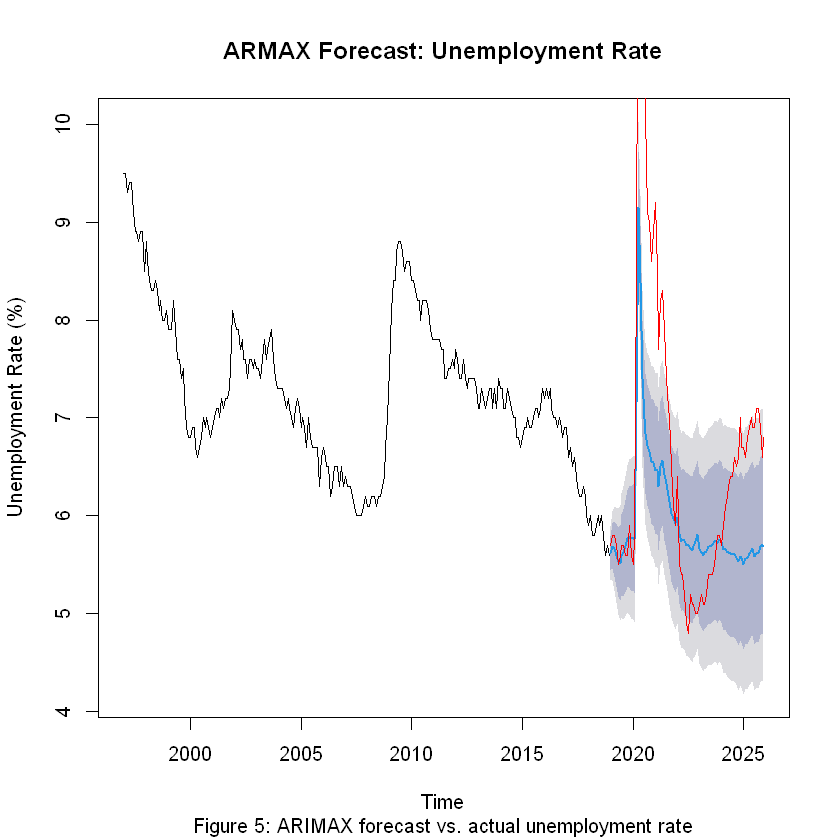

In [71]:
plot(armax_fc_auto,
     main = "ARMAX Forecast: Unemployment Rate",
     ylab = "Unemployment Rate (%)",
     xlab = "Time",
     sub = "Figure 5: ARIMAX forecast vs. actual unemployment rate")

lines(unemp_test, col = "red")
accuracy(armax_fc_auto, unemp_test)


	Ljung-Box test

data:  Residuals from Regression with ARIMA(0,1,1)(0,0,2)[12] errors
Q* = 16.643, df = 21, p-value = 0.7325

Model df: 3.   Total lags used: 24




	Box-Ljung test

data:  residuals(armax_model_auto)
X-squared = 15.953, df = 20, p-value = 0.7195


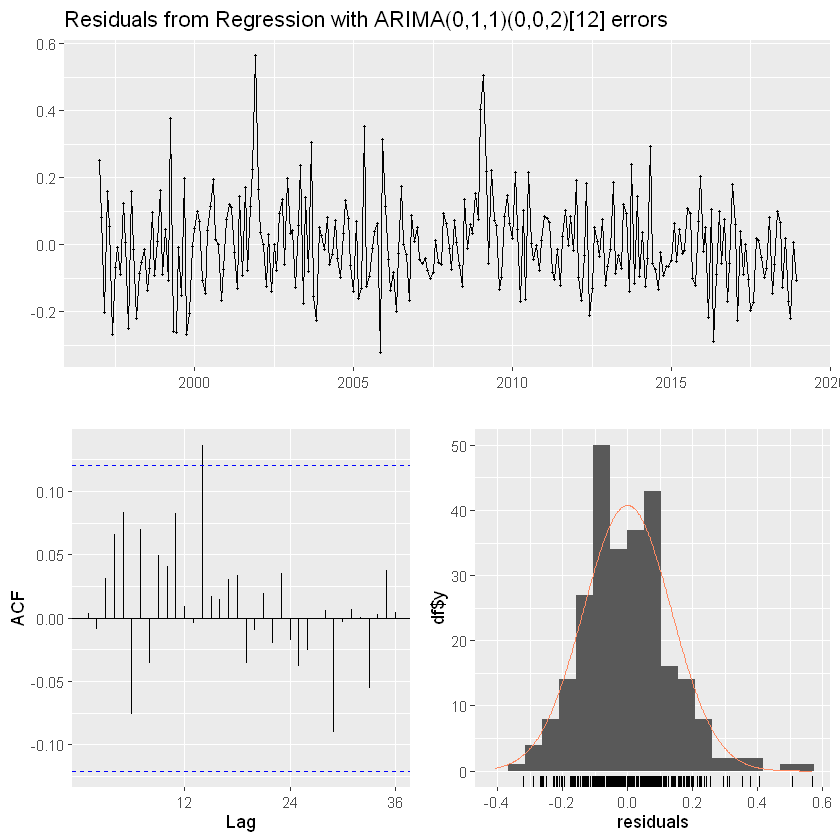

In [72]:
checkresiduals(armax_fc_auto)
Box.test(residuals(armax_model_auto), lag = 20, type = "Ljung-Box")

Since our p-value for the auto fitted ARMAX model is 0.7325 > 0.05, show our model has captured most mathematical patterns in the data. This is also apparent as our residuals are mostly random noise (except for a few large spikes).

Like this ARIMA model, the ARMAX model too failed to perform well for the large spike during 2020, but the 95% confidence interval usually captures the true value of unemployment percentage.

# More models with slight variation to see if they perform better on out of sample data.

In [ ]:
model_1 <- Arima(unemp_train, xreg = xreg_train, order = c(0, 1, 1), seasonal = c(0, 0, 1), include.drift = TRUE)
model_2 <- Arima(unemp_train, xreg = xreg_train, order = c(0, 1, 0), seasonal = c(0, 0, 1), include.drift = TRUE)
model_3 <- Arima(unemp_train, xreg = xreg_train, order = c(1, 1, 0), seasonal = c(0, 0, 1), include.drift = TRUE)
model_4 <- Arima(unemp_train, xreg = xreg_train, order = c(1, 1, 1), seasonal = c(0, 0, 1), include.drift = TRUE)
model_5 <- Arima(unemp_train, xreg = xreg_train, order = c(0, 1, 2), seasonal = c(0, 0, 1), include.drift = TRUE)

model_6  <- Arima(unemp_train, xreg = xreg_train, order = c(0, 1, 1), seasonal = c(0, 1, 1))
model_7  <- Arima(unemp_train, xreg = xreg_train, order = c(0, 1, 0), seasonal = c(0, 1, 1))
model_8  <- Arima(unemp_train, xreg = xreg_train, order = c(1, 1, 0), seasonal = c(0, 1, 1))
model_9  <- Arima(unemp_train, xreg = xreg_train, order = c(1, 1, 1), seasonal = c(0, 1, 1))
model_10 <- Arima(unemp_train, xreg = xreg_train, order = c(0, 1, 2), seasonal = c(0, 1, 1))
# model_11 is the original baseline model
model_11 <- Arima(unemp_train, xreg = xreg_train, order = c(0, 1, 1), seasonal = c(0, 0, 2), include.drift = TRUE)
model_12 <- Arima(unemp_train, xreg = xreg_train, order = c(0, 1, 0), seasonal = c(0, 0, 2), include.drift = TRUE)
model_13 <- Arima(unemp_train, xreg = xreg_train, order = c(1, 1, 0), seasonal = c(0, 0, 2), include.drift = TRUE)
model_14 <- Arima(unemp_train, xreg = xreg_train, order = c(1, 1, 1), seasonal = c(0, 0, 2), include.drift = TRUE)
model_15 <- Arima(unemp_train, xreg = xreg_train, order = c(0, 1, 2), seasonal = c(0, 0, 2), include.drift = TRUE)

armax_fc_1  <- forecast(model_1,  xreg = xreg_test)
armax_fc_2  <- forecast(model_2,  xreg = xreg_test)
armax_fc_3  <- forecast(model_3,  xreg = xreg_test)
armax_fc_4  <- forecast(model_4,  xreg = xreg_test)
armax_fc_5  <- forecast(model_5,  xreg = xreg_test)

armax_fc_6  <- forecast(model_6,  xreg = xreg_test)
armax_fc_7  <- forecast(model_7,  xreg = xreg_test)
armax_fc_8  <- forecast(model_8,  xreg = xreg_test)
armax_fc_9  <- forecast(model_9,  xreg = xreg_test)
armax_fc_10 <- forecast(model_10, xreg = xreg_test)

armax_fc_11 <- forecast(model_11, xreg = xreg_test)
armax_fc_12 <- forecast(model_12, xreg = xreg_test)
armax_fc_13 <- forecast(model_13, xreg = xreg_test)
armax_fc_14 <- forecast(model_14, xreg = xreg_test)
armax_fc_15 <- forecast(model_15, xreg = xreg_test)

accuracy(armax_fc_1,  unemp_test)
accuracy(armax_fc_2,  unemp_test)
accuracy(armax_fc_3,  unemp_test)
accuracy(armax_fc_4,  unemp_test)
accuracy(armax_fc_5,  unemp_test)

accuracy(armax_fc_6,  unemp_test)
accuracy(armax_fc_7,  unemp_test)
accuracy(armax_fc_8,  unemp_test)
accuracy(armax_fc_9,  unemp_test)
accuracy(armax_fc_10, unemp_test)

accuracy(armax_fc_11, unemp_test)
accuracy(armax_fc_12, unemp_test)
accuracy(armax_fc_13, unemp_test)
accuracy(armax_fc_14, unemp_test)
accuracy(armax_fc_15, unemp_test)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,4.285926e-05,0.1354542,0.105718,-0.03983024,1.456106,0.2060397,0.002092843,NA
Test set,8.574571e-01,1.5555810,1.041711,9.60503263,13.201507,2.0302496,0.922536527,1.811424


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-5.981716e-05,0.1360483,0.1059936,-0.0372763,1.459689,0.2065769,-0.09568596,NA
Test set,9.054060e-01,1.6126921,1.0751684,10.2524120,13.571872,2.0954557,0.92124722,1.87717


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,3.875563e-05,0.1354177,0.1057449,-0.03955735,1.456789,0.2060922,0.004892823,NA
Test set,8.593143e-01,1.5585105,1.0433656,9.62750723,13.220081,2.0334735,0.922448265,1.81467


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,4.726929e-05,0.1354086,0.1057373,-0.03931746,1.456751,0.2060772,0.005812298,NA
Test set,8.631594e-01,1.5626040,1.0458233,9.68113517,13.247136,2.0382634,0.922361435,1.819509


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,3.401031e-05,0.1353956,0.1057526,-0.03928172,1.457091,0.2061071,0.004872426,NA
Test set,8.622345e-01,1.5621842,1.0455140,9.66618905,13.244034,2.0376607,0.922355277,1.818848


...

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.0002100046,0.1346365,0.1047598,-0.04371199,1.442263,0.2041722,0.003474615,NA
Test set,0.7386363216,1.4952357,0.9964941,7.72621210,12.727591,1.9421231,0.923733039,1.732153


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.0003232806,0.1353387,0.1053025,-0.0408776,1.450058,0.2052299,-0.1016568,NA
Test set,0.7946366051,1.5561737,1.0313010,8.4960542,13.096121,2.0099602,0.9223600,1.799277


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.0002168359,0.1346202,0.1047734,-0.04327736,1.44276,0.2041987,0.003128017,NA
Test set,0.7438923958,1.5010048,0.9997075,7.79815274,12.76102,1.9483859,0.923585319,1.738482


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.0002119412,0.1346278,0.1047624,-0.04356564,1.442416,0.2041773,0.004391877,NA
Test set,0.7401124850,1.4968339,0.9973892,7.74649180,12.736926,1.9438677,0.923691439,1.733905


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.000212497,0.134623,0.1047627,-0.0434849,1.442467,0.2041778,0.004593337,NA
Test set,0.741254473,1.498006,0.9980503,7.7624041,12.743772,1.9451561,0.923662806,1.735196


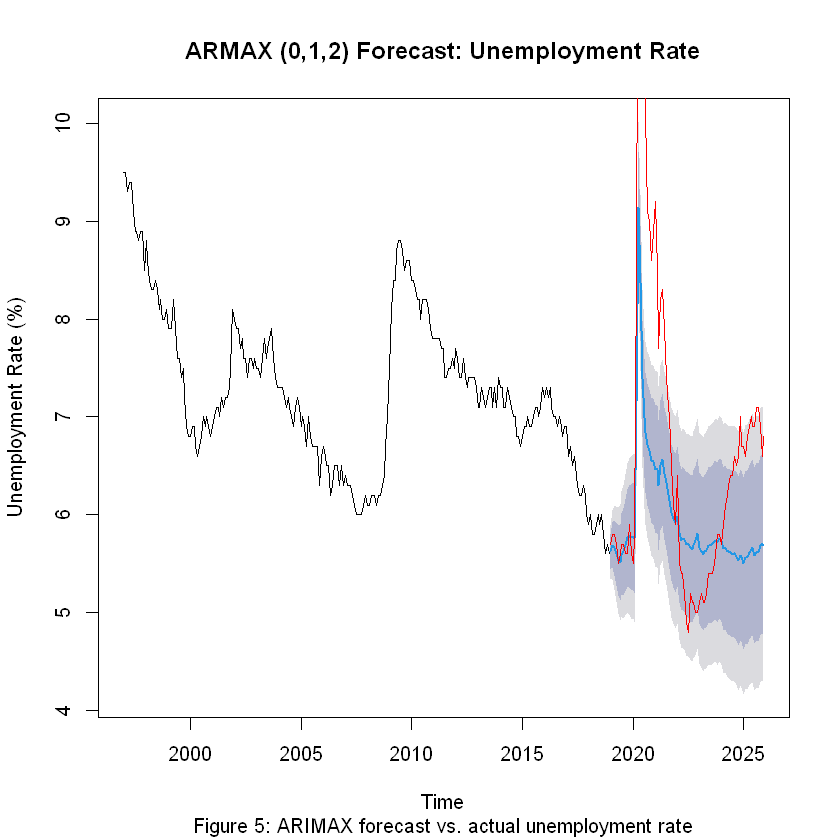

In [75]:
plot(armax_fc_15,
     main = "ARMAX (0,1,2) Forecast: Unemployment Rate",
     ylab = "Unemployment Rate (%)",
     xlab = "Time",
     sub = "Figure 5: ARIMAX forecast vs. actual unemployment rate")

lines(unemp_test, col = "red")


	Ljung-Box test

data:  Residuals from Regression with ARIMA(0,1,2)(0,0,2)[12] errors
Q* = 16.615, df = 20, p-value = 0.6778

Model df: 4.   Total lags used: 24




	Box-Ljung test

data:  residuals(armax_fc_15)
X-squared = 15.927, df = 20, p-value = 0.7212


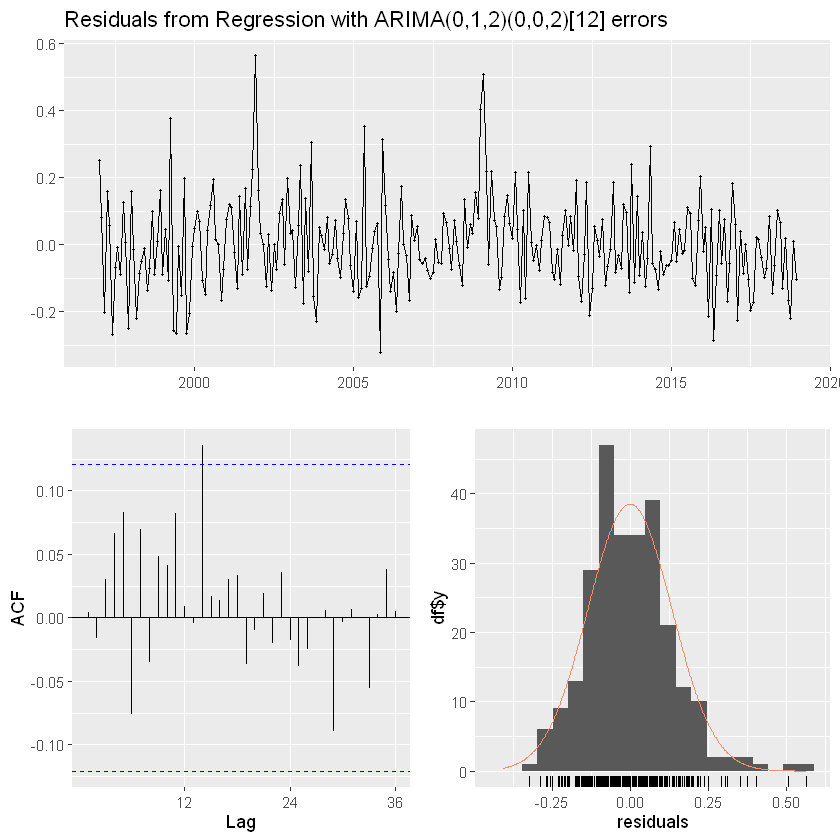

In [74]:
checkresiduals(armax_fc_15)
Box.test(residuals(armax_fc_15), lag = 20, type = "Ljung-Box")